In [1]:
import polars as pl
import time
start = time.time() 

df = pl.read_csv(
    "../data/raw/complaints.csv",
    columns=[
        'Complaint ID', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
        'Consumer complaint narrative', 'Company', 'State', 'Date received'
    ], 
    ignore_errors=True
)

print(f"Loaded in {time.time()-start:.1f}s — shape: {df.shape}")

Loaded in 589.4s — shape: (9609797, 9)


In [1]:

import pandas as pd
import gc
import os

df = pd.read_csv("../data/processed/filtered_complaints.csv")
print(f"Loaded: {df.shape}")
print(df['product_category'].value_counts())

Loaded: (346702, 11)
product_category
Credit Card        188606
Savings Account    139489
Personal Loan       17114
Money Transfer       1493
Name: count, dtype: int64


In [2]:
# Product distribution
print(df['Product'].value_counts())

# Narrative presence
has_narrative = df.filter(pl.col('Consumer complaint narrative').is_not_null()).height
total = df.height
print(f"With narrative: {has_narrative}/{total} ({has_narrative/total*100:.1f}%)")

shape: (21, 2)
┌─────────────────────────────────┬────────┐
│ Product                         ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Student loan                    ┆ 109717 │
│ Credit reporting                ┆ 140429 │
│ Money transfers                 ┆ 5354   │
│ Consumer Loan                   ┆ 31574  │
│ Payday loan                     ┆ 5541   │
│ …                               ┆ …      │
│ Credit card                     ┆ 226686 │
│ Vehicle loan or lease           ┆ 72957  │
│ Payday loan, title loan, perso… ┆ 16514  │
│ Checking or savings account     ┆ 291178 │
│ Credit card or prepaid card     ┆ 206369 │
└─────────────────────────────────┴────────┘
With narrative: 2980756/9609797 (31.0%)


In [3]:
# Product distribution
print(df['Product'].value_counts())

# Narrative presence
has_narrative = df.filter(pl.col('Consumer complaint narrative').is_not_null()).height
total = df.height
print(f"With narrative: {has_narrative}/{total} ({has_narrative/total*100:.1f}%)")

shape: (21, 2)
┌─────────────────────────────────┬─────────┐
│ Product                         ┆ count   │
│ ---                             ┆ ---     │
│ str                             ┆ u32     │
╞═════════════════════════════════╪═════════╡
│ Bank account or service         ┆ 86205   │
│ Credit card                     ┆ 226686  │
│ Other financial service         ┆ 1058    │
│ Money transfers                 ┆ 5354    │
│ Money transfer, virtual curren… ┆ 145066  │
│ …                               ┆ …       │
│ Student loan                    ┆ 109717  │
│ Prepaid card                    ┆ 15280   │
│ Credit reporting, credit repai… ┆ 2163857 │
│ Checking or savings account     ┆ 291178  │
│ Payday loan, title loan, or pe… ┆ 30641   │
└─────────────────────────────────┴─────────┘
With narrative: 2980756/9609797 (31.0%)


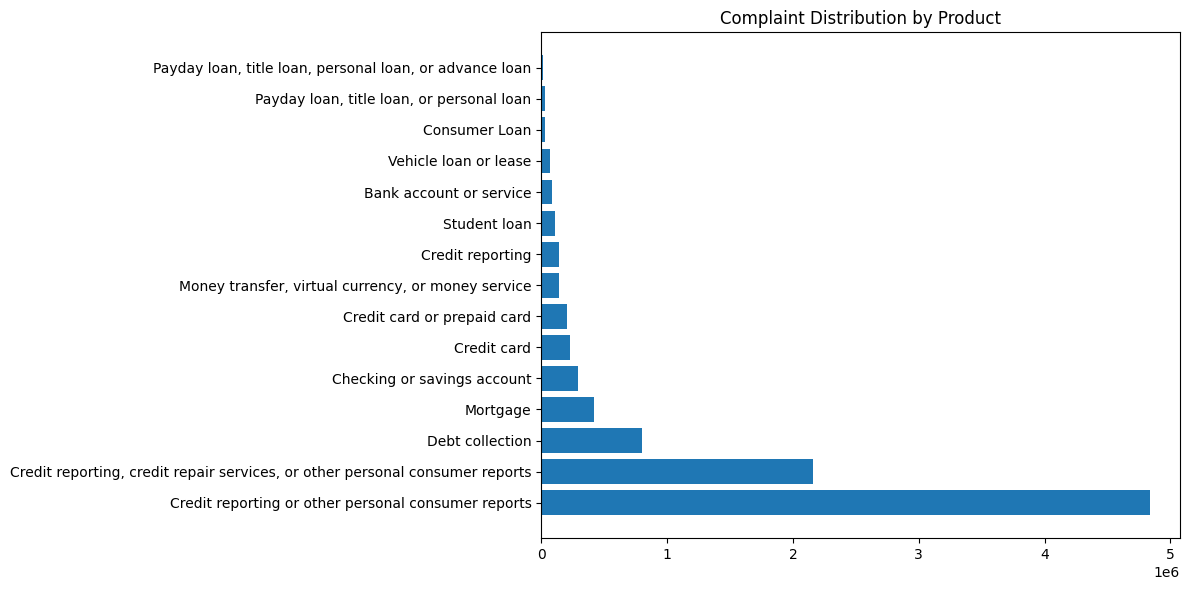

In [4]:
import matplotlib.pyplot as plt

product_counts = df['Product'].value_counts().sort('count', descending=True)
plt.figure(figsize=(12,6))
plt.barh(product_counts['Product'].to_list()[:15], product_counts['count'].to_list()[:15])
plt.title("Complaint Distribution by Product")
plt.tight_layout()
plt.savefig("../notebooks/product_distribution.png", dpi=150)
plt.show()

In [5]:
target_products = [
    'Credit card', 'Credit card or prepaid card',
    'Payday loan, title loan, or personal loan', 'Personal loan',
    'Checking or savings account',
    'Money transfer, virtual currency, or service', 'Money transfers'
]

df_filtered = df.filter(
    pl.col('Product').is_in(target_products) &
    pl.col('Consumer complaint narrative').is_not_null()
)

print(f"Filtered shape: {df_filtered.shape}")
print(df_filtered['Product'].value_counts())

Filtered shape: (348388, 9)
shape: (5, 2)
┌─────────────────────────────────┬────────┐
│ Product                         ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Credit card or prepaid card     ┆ 108667 │
│ Payday loan, title loan, or pe… ┆ 17238  │
│ Checking or savings account     ┆ 140319 │
│ Credit card                     ┆ 80667  │
│ Money transfers                 ┆ 1497   │
└─────────────────────────────────┴────────┘


In [6]:
target_products = [
    'Credit card', 'Credit card or prepaid card',
    'Payday loan, title loan, or personal loan', 'Personal loan',
    'Checking or savings account',
    'Money transfer, virtual currency, or service', 'Money transfers'
]

df_filtered = df.filter(
    pl.col('Product').is_in(target_products) &
    pl.col('Consumer complaint narrative').is_not_null()
)

print(f"Filtered shape: {df_filtered.shape}")
print(df_filtered['Product'].value_counts())

Filtered shape: (348388, 9)
shape: (5, 2)
┌─────────────────────────────────┬────────┐
│ Product                         ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Credit card                     ┆ 80667  │
│ Credit card or prepaid card     ┆ 108667 │
│ Payday loan, title loan, or pe… ┆ 17238  │
│ Money transfers                 ┆ 1497   │
│ Checking or savings account     ┆ 140319 │
└─────────────────────────────────┴────────┘


In [7]:
product_map = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Personal loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
}

df_filtered = df_filtered.with_columns(
    pl.col('Product').replace(product_map).alias('product_category')
)

print(df_filtered['product_category'].value_counts())

shape: (4, 2)
┌──────────────────┬────────┐
│ product_category ┆ count  │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ Credit Card      ┆ 189334 │
│ Personal Loan    ┆ 17238  │
│ Savings Account  ┆ 140319 │
│ Money Transfer   ┆ 1497   │
└──────────────────┴────────┘


In [8]:
import re

def clean_text(text):
    if text is None:
        return ""
    text = text.lower()
    text = re.sub(r'i (am writing|would like) to (file|report|complain|bring).*?\.', '', text)
    text = re.sub(r'\bxx+\b', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

narratives = df_filtered['Consumer complaint narrative'].to_list()
cleaned = [clean_text(t) for t in narratives]

df_filtered = df_filtered.with_columns(pl.Series('clean_narrative', cleaned))

# Drop near-empty after cleaning
df_filtered = df_filtered.filter(pl.col('clean_narrative').str.len_chars() > 50)

print(f"Final shape: {df_filtered.shape}")

Final shape: (346702, 11)


In [9]:
import os
os.makedirs("../data/processed", exist_ok=True)

df_filtered.write_csv("../data/processed/filtered_complaints.csv")
print("Saved filtered_complaints.csv ✅")

Saved filtered_complaints.csv ✅


In [1]:
import pandas as pd
import numpy as np
import pickle
import gc
import os
from sentence_transformers import SentenceTransformer
import faiss

# ── STEP 1: Load ──
df = pd.read_csv("../data/processed/filtered_complaints.csv")
print(f"✅ Loaded: {df.shape}")
print("Columns:", df.columns.tolist())  # shows exact column names

# ── STEP 2: Sample ──
# Use exact column name from what prints above
cat_col = 'product_category'
if cat_col not in df.columns:
    cat_col = [c for c in df.columns if 'category' in c.lower()][0]
print(f"Using category column: {cat_col}")

sample = df.groupby(cat_col, group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 3000), random_state=42)
).reset_index(drop=True)
del df
gc.collect()
print(f"✅ Sample size: {len(sample)}")

# ── STEP 3: Chunk ──
def simple_chunk(text, chunk_size=500, overlap=50):
    result = []
    start = 0
    while start < len(text):
        result.append(text[start:start + chunk_size])
        start += chunk_size - overlap
    return result

chunks = []
for _, row in sample.iterrows():
    text = str(row.get('Consumer complaint narrative', ''))
    if len(text) < 50:
        continue
    for i, chunk_text in enumerate(simple_chunk(text)):
        chunks.append({
            "text": chunk_text,
            "complaint_id": str(row.get('Complaint ID', '')),
            "product_category": str(row.get(cat_col, '')),
            "chunk_index": i
        })
del sample
gc.collect()
print(f"✅ Total chunks: {len(chunks)}")

# ── STEP 4: Embed + Save ──
model = SentenceTransformer('all-MiniLM-L6-v2')
texts = [c['text'] for c in chunks]
print(f"Embedding {len(texts)} chunks... please wait")

embeddings = model.encode(texts, batch_size=16, show_progress_bar=True)
embeddings = np.array(embeddings).astype('float32')

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

os.makedirs("../vector_store", exist_ok=True)
faiss.write_index(index, "../vector_store/faiss_index.bin")
with open("../vector_store/chunk_metadata.pkl", "wb") as f:
    pickle.dump(chunks, f)

print(f"\n🎉 TASK 2 COMPLETE!")
print(f"Chunks: {len(chunks)}")
print(f"Saved: vector_store/faiss_index.bin")
print(f"Saved: vector_store/chunk_metadata.pkl")

✅ Loaded: (346702, 11)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company', 'State', 'Complaint ID', 'product_category', 'clean_narrative']
Using category column: product_category
✅ Sample size: 10493
✅ Total chunks: 33351


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\ekram\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ekram\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 33351 chunks... please wait


Batches:   0%|          | 0/2085 [00:00<?, ?it/s]


🎉 TASK 2 COMPLETE!
Chunks: 33351
Saved: vector_store/faiss_index.bin
Saved: vector_store/chunk_metadata.pkl
